# QQ Plots

QQ plots are also a very well known tool to visualize GWAS results, and its goal is to visualize the distribution of association $p$-values.

In this notebook we intend to show how can be used the library `IDEAL-GENOM` to generate QQ-plots. 

In [2]:
import sys
import os

import pandas as pd

In [3]:
# add parent directory to path
library_path = os.path.abspath('..')
if library_path not in sys.path:
    sys.path.append(library_path)

In [4]:
from ideal_genom.visualizations.plots import qqplot_draw
from ideal_genom.core.get_examples import get_trumpet_quantitative_example

The data is taken from the article:

Akiyama, M., et. al. (2019): Characterizing rare and low-frequency height-associated variants in the Japanese population. *Nature communications*, **10**(1), 4393.

It the summary statistics has not been downloaded already, we proceed to fetch it or we get the path to it.

In [5]:
example_path = get_trumpet_quantitative_example()

2026-01-26 13:31:14,246 - INFO - File already exists: /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats/2019_BBJ_Height_autosomes_BOLT.txt


We load the data by chunks given that the file is not smallm and we just keep the two columns with $p$-values.

In [6]:
chunk_size = 2000

filtered_chunks=[]

for chunk in pd.read_csv(example_path, sep=r'\s+', engine='python', chunksize=chunk_size, usecols=['P_INF', 'P_BOLT']):
    
    filtered_chunks.append(chunk)

df_gwas = pd.concat(filtered_chunks, ignore_index=True)

Let us look at how many SNPs from autosomal chromosomes are present in the summary statistics.

In [7]:
print("Number of SNPs in GWAS data: ", df_gwas.shape[0])
print("Columns in GWAS data: ", df_gwas.columns.to_list())

Number of SNPs in GWAS data:  27211524
Columns in GWAS data:  ['P_INF', 'P_BOLT']


Generate the QQ values for the p-values from the summary statistics.

2026-01-26 13:33:57,900 - INFO - Calculating genomic inflation factor (λ)...
2026-01-26 13:35:28,122 - INFO - Genomic inflation factor (λ) = 1.199936
2026-01-26 13:35:33,454 - INFO - Computing confidence intervals...
2026-01-26 13:35:33,940 - INFO - Plotting Q-Q plot...


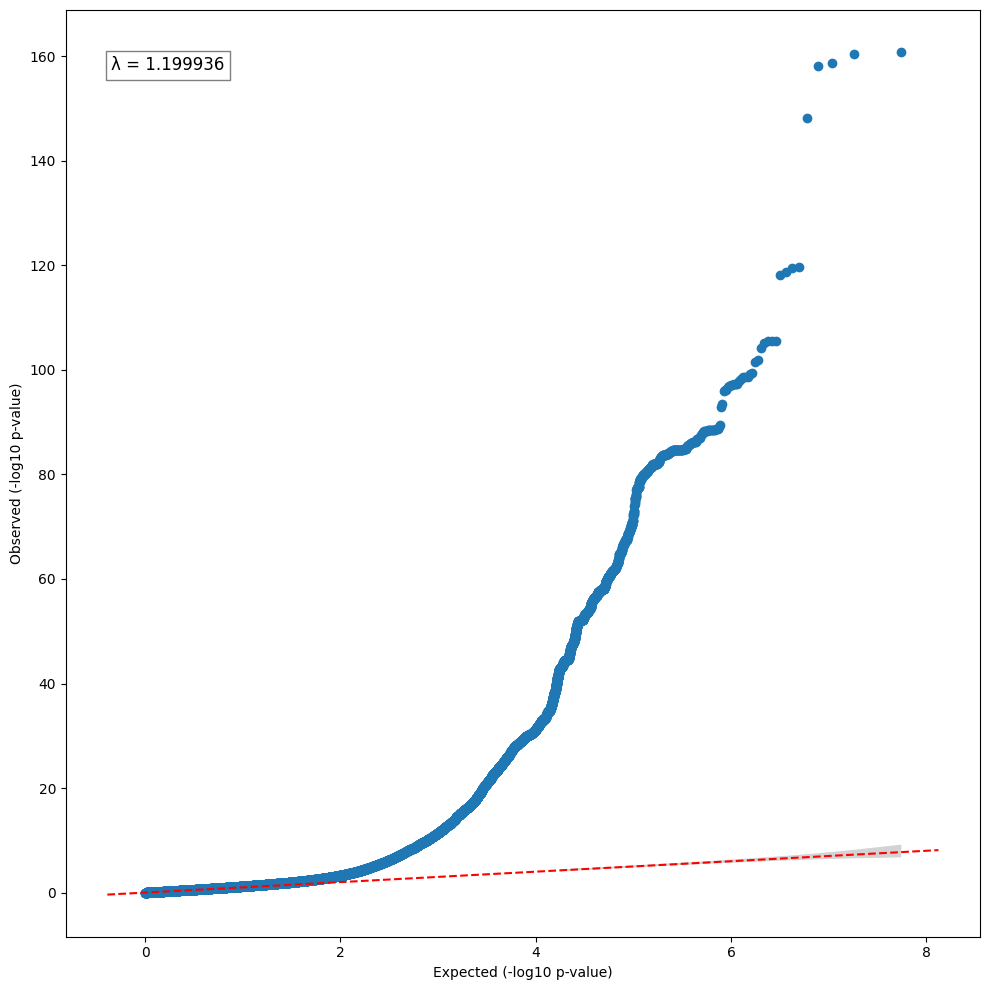

2026-01-26 13:35:35,497 - INFO - Q-Q plot saved as unadjusted_qqplot_gwas.png in /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats


True

In [8]:
qqplot_draw(
    df_gwas=df_gwas,
    plots_dir=example_path.parent.as_posix(),
    pval_col='P_INF',
    save_name='unadjusted_qqplot_gwas.png',
    dpi=600
)

Generate the QQ plot for the adjusted $p$-values.

2026-01-26 13:43:05,363 - INFO - Calculating genomic inflation factor (λ)...
2026-01-26 13:44:35,678 - INFO - Genomic inflation factor (λ) = 1.199936
2026-01-26 13:44:41,030 - INFO - Computing confidence intervals...
2026-01-26 13:44:41,508 - INFO - Plotting Q-Q plot...


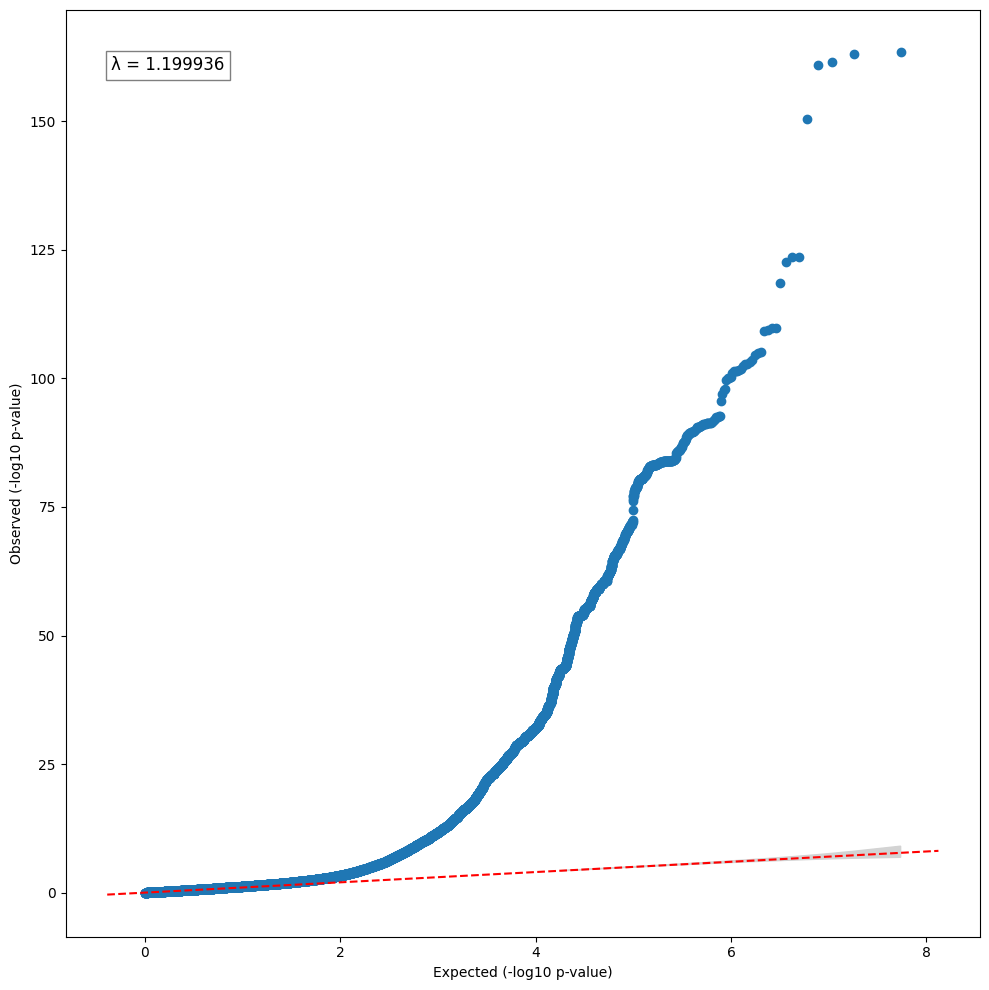

2026-01-26 13:44:43,195 - INFO - Q-Q plot saved as adjusted_qqplot_gwas.png in /mnt/DataVol/CGE/IDEAL-GENOM/ideal_genom/data/sumstats


True

In [9]:
qqplot_draw(
    df_gwas=df_gwas,
    plots_dir=example_path.parent.as_posix(),
    pval_col='P_BOLT',
    save_name='adjusted_qqplot_gwas.png',
    dpi=600
)